# Projet 7 - Augmented Alzheimer Dataset Classical ML Pipeline (SVM / KNN / Random Forest)

Pipeline: loading -> resize -> HSV -> HOG -> HSV hist -> LBP -> concat -> standardization -> PCA -> SVM/KNN/RF -> evaluation.
Dataset: `Dataset/AugmentedAlzheimerDataset` (4 classes), custom split with `train_test_split`, SEED=42.


In [16]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn scikit-image scipy pywavelets tqdm pillow


Note: you may need to restart the kernel to use updated packages.


In [17]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
from sklearn.decomposition import PCA

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.filters import gaussian
from skimage import exposure
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
import pywt

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")



## 1) Dataset Loading + MRI-Oriented Preprocessing


Loading MildDemented:   0%|          | 0/8933 [00:00<?, ?it/s]

Loading ModerateDemented:   0%|          | 0/6464 [00:00<?, ?it/s]

Loading NonDemented:   0%|          | 0/9600 [00:00<?, ?it/s]

Loading VeryMildDemented:   0%|          | 0/8960 [00:00<?, ?it/s]

Dataset path : Dataset\AugmentedAlzheimerDataset
Image size   : (128, 128)
Train: (27165, 128, 128) (27165,)
Test : (6792, 128, 128) (6792,)
Classes: 4 ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Train counts: [7146 5171 7680 7168]
Test counts : [1787 1293 1920 1792]


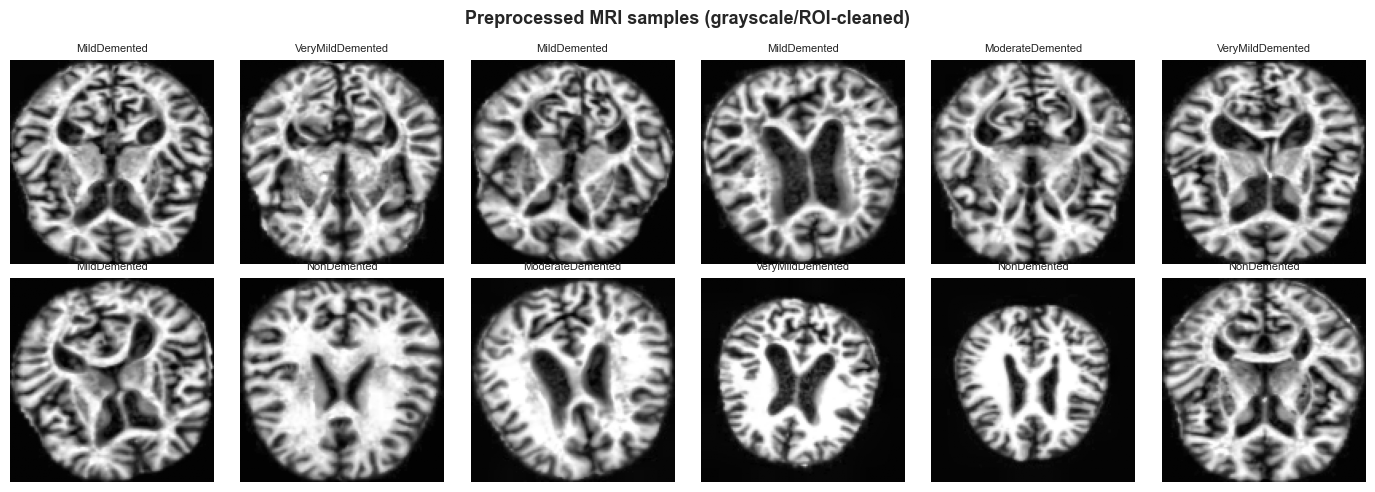

In [18]:
# Dataset-specific config
DATASET_DIR = Path("Dataset/AugmentedAlzheimerDataset")
TARGET_SIZE = (128, 128)
TEST_SIZE = 0.2
MAX_SAMPLES_PER_CLASS = None  # Example: 3000 for faster experimentation
USE_CLAHE = True

def crop_black_background(img_gray, threshold=0.05):
    mask = img_gray > threshold
    if not np.any(mask):
        return img_gray
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return img_gray[y0:y1, x0:x1]

def preprocess_mri_image(img, target_size=(128, 128), use_clahe=True):
    if img.ndim == 3:
        img = rgb2gray(img)
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0

    img = crop_black_background(img, threshold=0.05)
    img = resize(img, target_size, anti_aliasing=True, preserve_range=True).astype(np.float32)
    img = gaussian(img, sigma=0.5, preserve_range=True).astype(np.float32)

    # Normalize to [0, 1]
    img_min, img_max = img.min(), img.max()
    img = (img - img_min) / (img_max - img_min + 1e-9)

    # Optional contrast enhancement
    if use_clahe:
        img = exposure.equalize_adapthist(img, clip_limit=0.02)
        img = np.clip(img, 0, 1)

    return img.astype(np.float32)

def load_alzheimer_dataset(dataset_dir, target_size=(128, 128), max_samples_per_class=None):
    class_names_local = sorted([d.name for d in dataset_dir.iterdir() if d.is_dir()])
    X_list, y_list = [], []
    rng = np.random.default_rng(SEED)

    for class_idx, class_name in enumerate(class_names_local):
        class_dir = dataset_dir / class_name
        paths = [p for p in class_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
        if max_samples_per_class is not None and len(paths) > max_samples_per_class:
            chosen = rng.choice(len(paths), size=max_samples_per_class, replace=False)
            paths = [paths[i] for i in chosen]

        for img_path in tqdm(paths, desc=f"Loading {class_name}"):
            try:
                img = imread(img_path)
                img_pp = preprocess_mri_image(img, target_size=target_size, use_clahe=USE_CLAHE)
                X_list.append(img_pp)
                y_list.append(class_idx)
            except Exception:
                continue

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    return X, y, class_names_local

X_all, y_all, class_names = load_alzheimer_dataset(
    DATASET_DIR,
    target_size=TARGET_SIZE,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_all
)

print("Dataset path :", DATASET_DIR)
print("Image size   :", TARGET_SIZE)
print("Train:", X_train_raw.shape, y_train.shape)
print("Test :", X_test_raw.shape, y_test.shape)
print("Classes:", len(class_names), class_names)
print("Train counts:", np.bincount(y_train, minlength=len(class_names)))
print("Test counts :", np.bincount(y_test, minlength=len(class_names)))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
idx = np.random.choice(len(X_train_raw), size=min(12, len(X_train_raw)), replace=False)
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X_train_raw[i], cmap="gray")
    ax.set_title(class_names[y_train[i]], fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[len(idx):]:
    ax.axis("off")
plt.suptitle("Preprocessed MRI samples (grayscale/ROI-cleaned)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



## 2) Feature Branch A - First-Order Statistics


In [19]:
def first_order_features(img):
    vals = img.ravel()
    hist, _ = np.histogram(vals, bins=64, range=(0, 1), density=True)
    hist = hist + 1e-12
    hist = hist / hist.sum()
    entropy = -(hist * np.log2(hist)).sum()
    p10, p25, p50, p75, p90 = np.percentile(vals, [10, 25, 50, 75, 90])
    return np.array([
        vals.mean(),
        vals.std(),
        vals.var(),
        entropy,
        skew(vals),
        kurtosis(vals),
        p10, p25, p50, p75, p90
    ], dtype=np.float32)

X_train_stats = np.vstack([first_order_features(x) for x in tqdm(X_train_raw, desc="Stats train")])
X_test_stats = np.vstack([first_order_features(x) for x in tqdm(X_test_raw, desc="Stats test")])
print("Branch A shapes:", X_train_stats.shape, X_test_stats.shape)



Stats train:   0%|          | 0/27165 [00:00<?, ?it/s]

Stats test:   0%|          | 0/6792 [00:00<?, ?it/s]

Branch A shapes: (27165, 11) (6792, 11)


## 3) Feature Branch B - Texture (GLCM + LBP)


In [20]:
def texture_features(img):
    img_u8 = (img * 255).astype(np.uint8)

    # GLCM
    distances = [1, 2, 4]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(img_u8, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
    glcm_feats = []
    for p_name in props:
        glcm_feats.append(graycoprops(glcm, p_name).mean())

    # LBP histogram
    P, R = 16, 2
    lbp = local_binary_pattern(img, P=P, R=R, method="uniform")
    n_bins = P + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), density=True)
    lbp_hist = lbp_hist.astype(np.float32)

    return np.hstack([np.array(glcm_feats, dtype=np.float32), lbp_hist]).astype(np.float32)

X_train_tex = np.vstack([texture_features(x) for x in tqdm(X_train_raw, desc="Texture train")])
X_test_tex = np.vstack([texture_features(x) for x in tqdm(X_test_raw, desc="Texture test")])
print("Branch B shapes:", X_train_tex.shape, X_test_tex.shape)



Texture train:   0%|          | 0/27165 [00:00<?, ?it/s]

c:\Users\FERRA\.conda\envs\dl\lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Texture test:   0%|          | 0/6792 [00:00<?, ?it/s]

Branch B shapes: (27165, 24) (6792, 24)


## 4) Feature Branch C - Wavelet (DWT)


In [21]:
def band_stats(band):
    vals = band.ravel().astype(np.float32)
    energy = np.mean(vals ** 2)
    hist, _ = np.histogram(vals, bins=64, density=True)
    hist = hist + 1e-12
    hist = hist / hist.sum()
    ent = -(hist * np.log2(hist)).sum()
    return [vals.mean(), vals.std(), energy, ent]

def wavelet_features(img, wavelet="db2"):
    LL, (LH, HL, HH) = pywt.dwt2(img, wavelet=wavelet)
    feats = []
    for b in [LL, LH, HL, HH]:
        feats.extend(band_stats(b))
    return np.array(feats, dtype=np.float32)

X_train_wav = np.vstack([wavelet_features(x) for x in tqdm(X_train_raw, desc="Wavelet train")])
X_test_wav = np.vstack([wavelet_features(x) for x in tqdm(X_test_raw, desc="Wavelet test")])
print("Branch C shapes:", X_train_wav.shape, X_test_wav.shape)



Wavelet train:   0%|          | 0/27165 [00:00<?, ?it/s]

Wavelet test:   0%|          | 0/6792 [00:00<?, ?it/s]

Branch C shapes: (27165, 16) (6792, 16)


## 5) Feature Branch D - HOG


In [22]:
def hog_features(img):
    return hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    ).astype(np.float32)

X_train_hog = np.vstack([hog_features(x) for x in tqdm(X_train_raw, desc="HOG train")])
X_test_hog = np.vstack([hog_features(x) for x in tqdm(X_test_raw, desc="HOG test")])
print("Branch D shapes:", X_train_hog.shape, X_test_hog.shape)



HOG train:   0%|          | 0/27165 [00:00<?, ?it/s]

HOG test:   0%|          | 0/6792 [00:00<?, ?it/s]

Branch D shapes: (27165, 8100) (6792, 8100)


## 6) Feature Fusion


In [23]:
X_train_feat = np.hstack([X_train_stats, X_train_tex, X_train_wav, X_train_hog]).astype(np.float32)
X_test_feat = np.hstack([X_test_stats, X_test_tex, X_test_wav, X_test_hog]).astype(np.float32)
print("Fused shape:", X_train_feat.shape, X_test_feat.shape)



Fused shape: (27165, 8151) (6792, 8151)


## 7) Feature Space Cleaning (constant + correlation) and Scaling


In [24]:
# Remove constant features
vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train_feat)
X_test_vt = vt.transform(X_test_feat)
print("After variance threshold:", X_train_vt.shape[1], "features")

# Remove highly correlated features
corr = pd.DataFrame(X_train_vt).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
keep_mask = np.ones(X_train_vt.shape[1], dtype=bool)
if len(to_drop) > 0:
    keep_mask[np.array(to_drop, dtype=int)] = False
X_train_clean = X_train_vt[:, keep_mask]
X_test_clean = X_test_vt[:, keep_mask]
print("After correlation filter:", X_train_clean.shape[1], "features")

# Scaling (required for SVM/KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)



After variance threshold: 8148 features
After correlation filter: 3990 features


## 8) Feature Selection + PCA Variants


After Stage A (ANOVA): 1200 features
After Stage B (RF importance): 400 features
PCA95 shape: (27165, 269) (6792, 269)
PCA fixed shape: (27165, 120) (6792, 120)


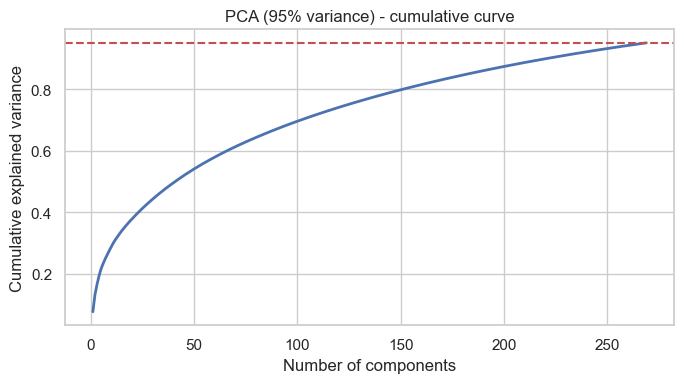

In [25]:
# Stage A: Univariate filtering (ANOVA F-score; switch to mutual_info if needed)
k_a = min(1200, X_train_scaled.shape[1])
selector_a = SelectKBest(score_func=f_classif, k=k_a)
X_train_a = selector_a.fit_transform(X_train_scaled, y_train)
X_test_a = selector_a.transform(X_test_scaled)
print("After Stage A (ANOVA):", X_train_a.shape[1], "features")

# Stage B: Embedded ranking (Random Forest importance)
rf_ranker = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_ranker.fit(X_train_a, y_train)
importances = rf_ranker.feature_importances_
k_b = min(400, X_train_a.shape[1])
top_idx = np.argsort(importances)[::-1][:k_b]
X_train_sel = X_train_a[:, top_idx]
X_test_sel = X_test_a[:, top_idx]
print("After Stage B (RF importance):", X_train_sel.shape[1], "features")

# PCA variants
pca95 = PCA(n_components=0.95, random_state=SEED)
X_train_pca95 = pca95.fit_transform(X_train_sel)
X_test_pca95 = pca95.transform(X_test_sel)
print("PCA95 shape:", X_train_pca95.shape, X_test_pca95.shape)

pca_fixed_n = min(120, X_train_sel.shape[1], X_train_sel.shape[0] - 1)
pca_fixed = PCA(n_components=pca_fixed_n, random_state=SEED)
X_train_pca_fixed = pca_fixed.fit_transform(X_train_sel)
X_test_pca_fixed = pca_fixed.transform(X_test_sel)
print("PCA fixed shape:", X_train_pca_fixed.shape, X_test_pca_fixed.shape)

# Optional explained variance plot
cum = np.cumsum(pca95.explained_variance_ratio_)
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cum) + 1), cum, lw=2)
plt.axhline(0.95, color="r", ls="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA (95% variance) - cumulative curve")
plt.tight_layout()
plt.show()



## 9) SVM Training (linear + RBF on multiple feature views)


In [28]:
svm_feature_sets = {
    "selected_no_pca": (X_train_sel, X_test_sel),
    "pca95": (X_train_pca95, X_test_pca95),
    "pca_fixed": (X_train_pca_fixed, X_test_pca_fixed),
}

svm_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": ["scale"]
}

best_svm = None
best_svm_score = -np.inf
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

for fs_name, (Xtr, Xte) in svm_feature_sets.items():
    gs = GridSearchCV(
        SVC(random_state=SEED),
        param_grid=svm_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    t0 = time.time()
    gs.fit(Xtr, y_train)
    fit_time = time.time() - t0
    y_pred = gs.best_estimator_.predict(Xte)
    f1m = f1_score(y_test, y_pred, average="macro")
    print(f"[SVM][{fs_name}] best={gs.best_params_} | CV={gs.best_score_:.4f} | test_f1_macro={f1m:.4f}")
    if f1m > best_svm_score:
        best_svm_score = f1m
        best_svm = (fs_name, gs.best_estimator_, fit_time)

svm_best_set, svm_final, svm_fit_time = best_svm
X_train_svm, X_test_svm = svm_feature_sets[svm_best_set]
t0 = time.time()
y_pred_svm = svm_final.predict(X_test_svm)
svm_pred_time = time.time() - t0

print(f"Chosen SVM set: {svm_best_set}")
print(classification_report(y_test, y_pred_svm, target_names=class_names, digits=4))



[SVM][selected_no_pca] best={'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} | CV=0.9026 | test_f1_macro=0.9163
[SVM][pca95] best={'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} | CV=0.9019 | test_f1_macro=0.9152
[SVM][pca_fixed] best={'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} | CV=0.8930 | test_f1_macro=0.9066
Chosen SVM set: selected_no_pca
                  precision    recall  f1-score   support

    MildDemented     0.8839    0.9328    0.9077      1787
ModerateDemented     0.9806    0.9776    0.9791      1293
     NonDemented     0.9058    0.8964    0.9010      1920
VeryMildDemented     0.8963    0.8588    0.8772      1792

        accuracy                         0.9115      6792
       macro avg     0.9167    0.9164    0.9163      6792
    weighted avg     0.9118    0.9115    0.9114      6792



## 10) KNN Training (k, metric, weights)


In [30]:
knn_feature_sets = {
    "selected_no_pca": (X_train_sel, X_test_sel),
    "pca95": (X_train_pca95, X_test_pca95),
    "pca_fixed": (X_train_pca_fixed, X_test_pca_fixed),
}

knn_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"],
}

best_knn = None
best_knn_score = -np.inf
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

for fs_name, (Xtr, Xte) in knn_feature_sets.items():
    gs = GridSearchCV(
        KNeighborsClassifier(),
        param_grid=knn_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    t0 = time.time()
    gs.fit(Xtr, y_train)
    fit_time = time.time() - t0
    y_pred = gs.best_estimator_.predict(Xte)
    f1m = f1_score(y_test, y_pred, average="macro")
    print(f"[KNN][{fs_name}] best={gs.best_params_} | CV={gs.best_score_:.4f} | test_f1_macro={f1m:.4f}")
    if f1m > best_knn_score:
        best_knn_score = f1m
        best_knn = (fs_name, gs.best_estimator_, fit_time)

knn_best_set, knn_final, knn_fit_time = best_knn
X_train_knn, X_test_knn = knn_feature_sets[knn_best_set]
t0 = time.time()
y_pred_knn = knn_final.predict(X_test_knn)
knn_pred_time = time.time() - t0

print(f"Chosen KNN set: {knn_best_set}")
print(classification_report(y_test, y_pred_knn, target_names=class_names, digits=4))



[KNN][selected_no_pca] best={'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | CV=0.9053 | test_f1_macro=0.9219
[KNN][pca95] best={'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'} | CV=0.9047 | test_f1_macro=0.9156
[KNN][pca_fixed] best={'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'} | CV=0.8971 | test_f1_macro=0.9063
Chosen KNN set: selected_no_pca
                  precision    recall  f1-score   support

    MildDemented     0.8946    0.9407    0.9171      1787
ModerateDemented     0.9355    0.9869    0.9605      1293
     NonDemented     0.9323    0.8891    0.9102      1920
VeryMildDemented     0.9191    0.8811    0.8997      1792

        accuracy                         0.9192      6792
       macro avg     0.9204    0.9244    0.9219      6792
    weighted avg     0.9195    0.9192    0.9188      6792



## 11) Random Forest Training (selected features, optional PCA)


In [31]:
rf_feature_sets = {
    "selected_no_pca": (X_train_sel, X_test_sel),
    "pca95": (X_train_pca95, X_test_pca95),
}

rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 20, 40],
    "max_features": ["sqrt", "log2"],
}

best_rf = None
best_rf_score = -np.inf
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

for fs_name, (Xtr, Xte) in rf_feature_sets.items():
    gs = GridSearchCV(
        RandomForestClassifier(random_state=SEED, n_jobs=-1),
        param_grid=rf_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    t0 = time.time()
    gs.fit(Xtr, y_train)
    fit_time = time.time() - t0
    y_pred = gs.best_estimator_.predict(Xte)
    f1m = f1_score(y_test, y_pred, average="macro")
    print(f"[RF][{fs_name}] best={gs.best_params_} | CV={gs.best_score_:.4f} | test_f1_macro={f1m:.4f}")
    if f1m > best_rf_score:
        best_rf_score = f1m
        best_rf = (fs_name, gs.best_estimator_, fit_time)

rf_best_set, rf_final, rf_fit_time = best_rf
X_train_rf, X_test_rf = rf_feature_sets[rf_best_set]
t0 = time.time()
y_pred_rf = rf_final.predict(X_test_rf)
rf_pred_time = time.time() - t0

print(f"Chosen RF set: {rf_best_set}")
print(classification_report(y_test, y_pred_rf, target_names=class_names, digits=4))



[RF][selected_no_pca] best={'max_depth': None, 'max_features': 'log2', 'n_estimators': 400} | CV=0.8045 | test_f1_macro=0.8257
[RF][pca95] best={'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 400} | CV=0.7945 | test_f1_macro=0.8176
Chosen RF set: selected_no_pca
                  precision    recall  f1-score   support

    MildDemented     0.7374    0.8987    0.8101      1787
ModerateDemented     1.0000    0.9111    0.9535      1293
     NonDemented     0.7819    0.8177    0.7994      1920
VeryMildDemented     0.8340    0.6646    0.7398      1792

        accuracy                         0.8164      6792
       macro avg     0.8383    0.8230    0.8257      6792
    weighted avg     0.8255    0.8164    0.8158      6792



## 12) Final Evaluation (all models)


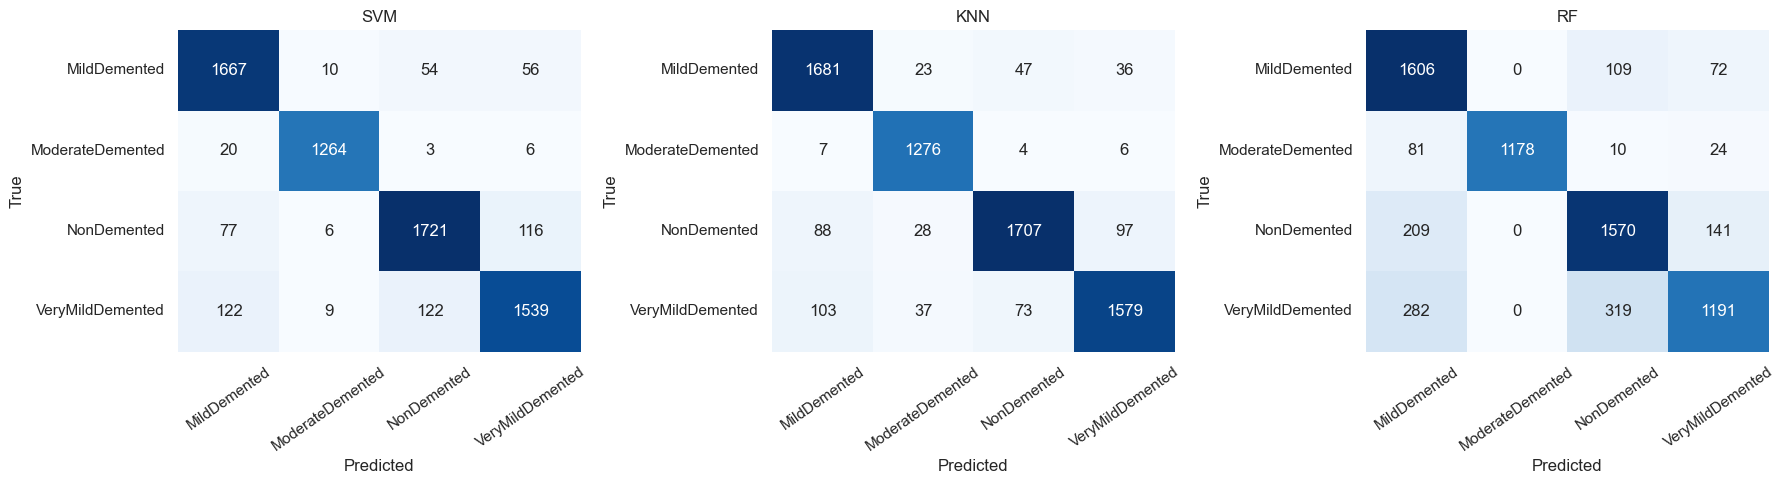

In [32]:
cms = {
    "SVM": confusion_matrix(y_test, y_pred_svm),
    "KNN": confusion_matrix(y_test, y_pred_knn),
    "RF": confusion_matrix(y_test, y_pred_rf),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(
        cm,
        ax=ax,
        cmap="Blues",
        fmt="d",
        annot=True,
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()



## 13) Comparative Analysis (Reference-style plots)

This section extends the baseline comparison with:
- normalized confusion matrices,
- macro and weighted metrics,
- per-class F1 heatmap,
- one-vs-rest ROC-AUC curves for the 4 Alzheimer classes,
- a compact overall ranking score.



       Accuracy  F1 macro  F1 weighted  Precision macro  Recall macro  \
Model                                                                   
KNN      0.9192    0.9219       0.9188           0.9204        0.9244   
SVM      0.9115    0.9163       0.9114           0.9167        0.9164   
RF       0.8164    0.8257       0.8158           0.8383        0.8230   

       Fit time (s)  Predict time (s)  
Model                                  
KNN        284.5459           18.0284  
SVM      22863.8838           50.7257  
RF         601.8011            0.5617  
Saved: alzheimer_ml_classique_results.csv


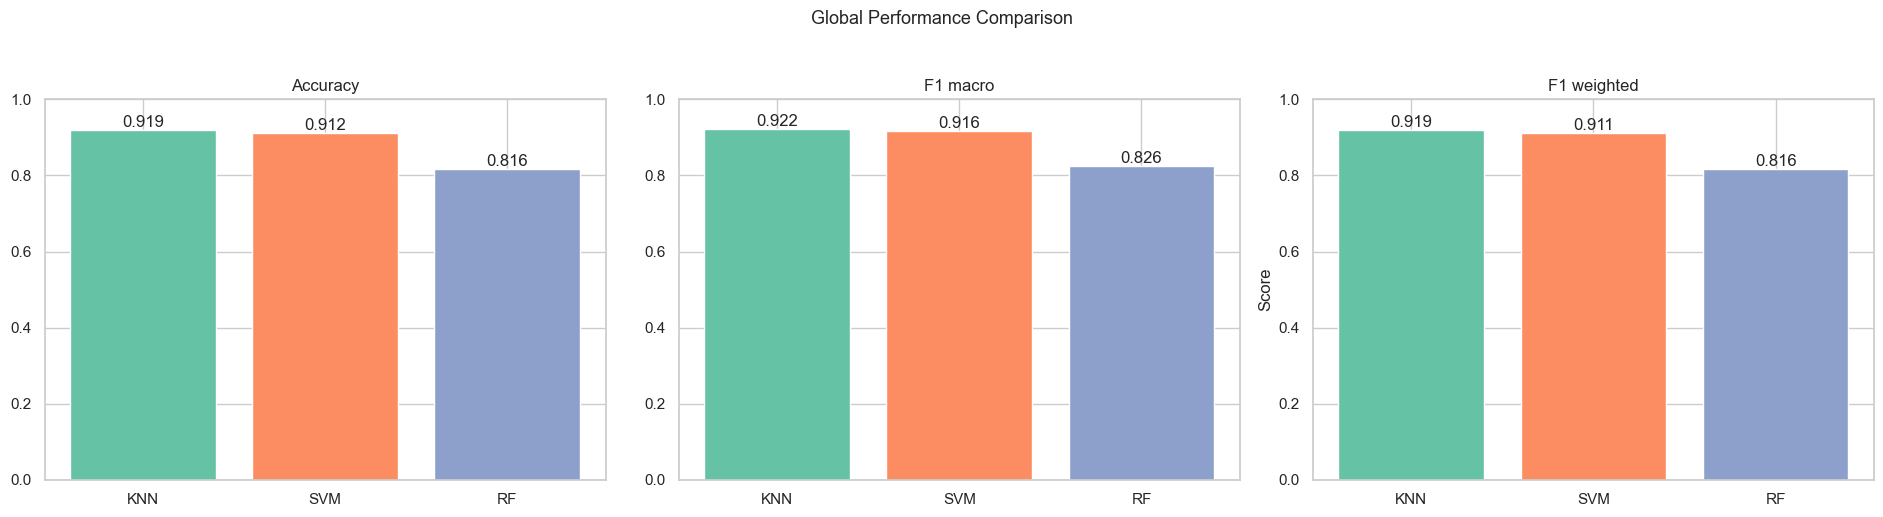

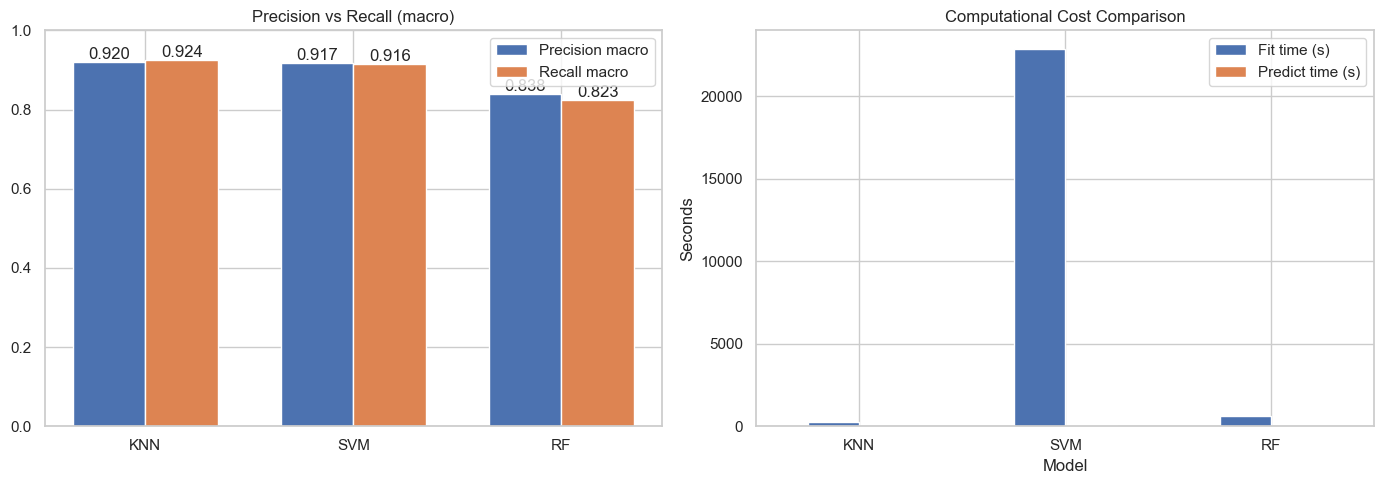

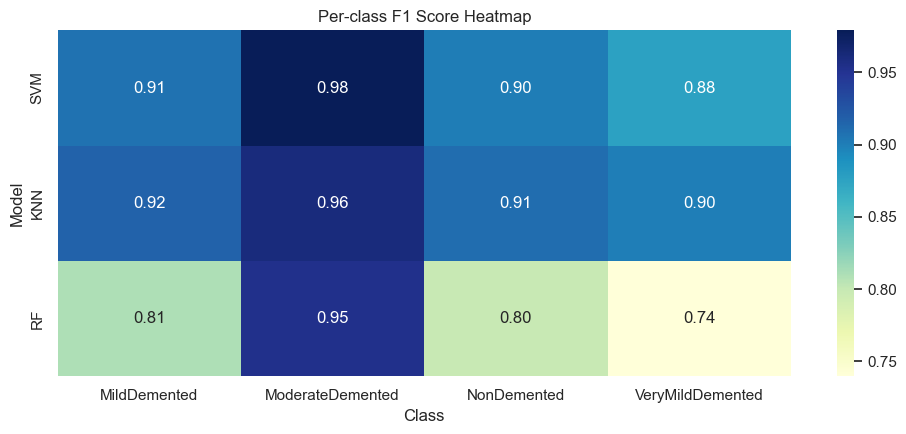

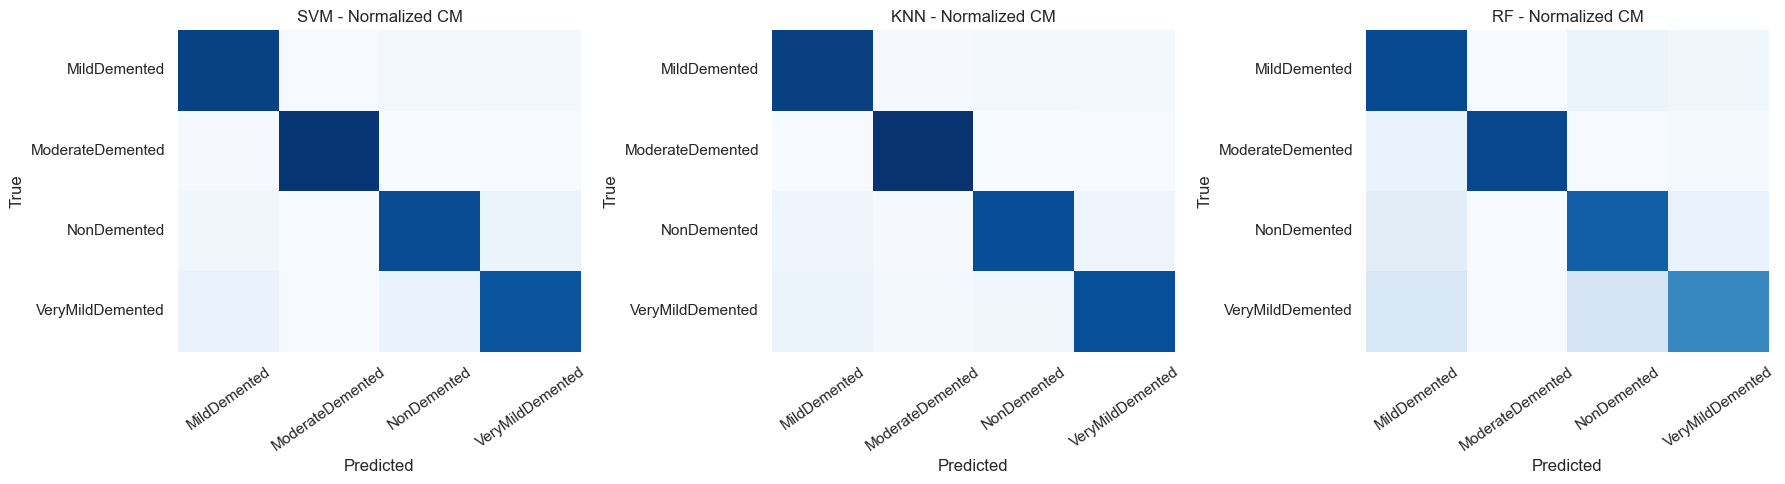

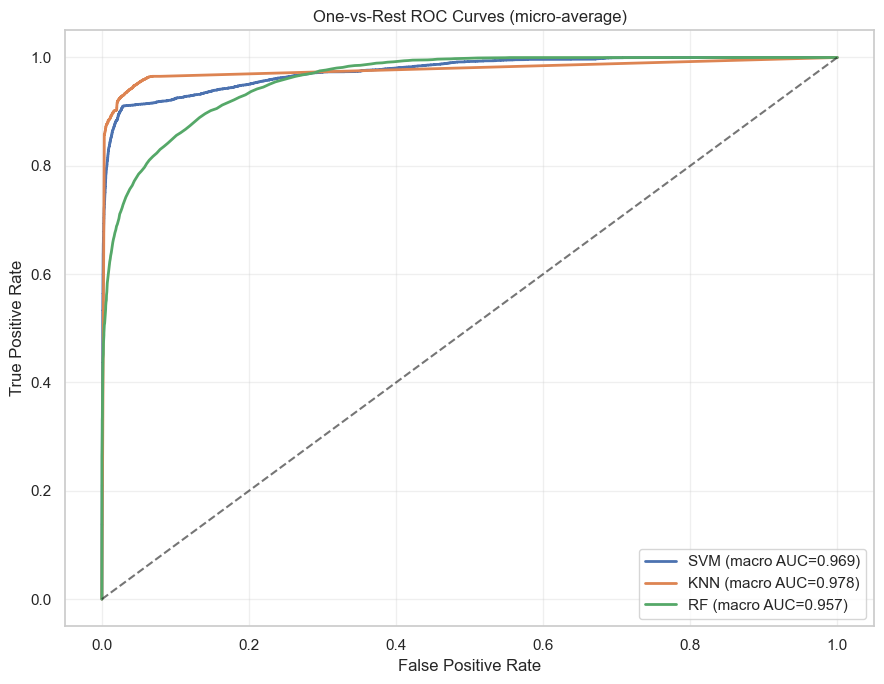


Composite ranking (higher is better):
       Accuracy  F1 macro  Fit time (s)  Predict time (s)  Composite score
Model                                                                     
KNN      0.9192    0.9219      284.5459           18.0284           0.7019
RF       0.8164    0.8257      601.8011            0.5617           0.6564
SVM      0.9115    0.9163    22863.8838           50.7257           0.5316


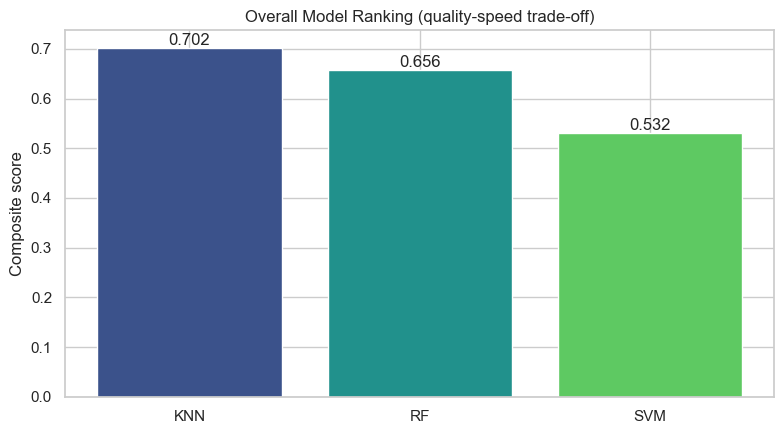

In [34]:
models = {
    "SVM": {
        "estimator": svm_final,
        "y_pred": y_pred_svm,
        "fit_t": svm_fit_time,
        "pred_t": svm_pred_time,
        "X_test": X_test_svm,
    },
    "KNN": {
        "estimator": knn_final,
        "y_pred": y_pred_knn,
        "fit_t": knn_fit_time,
        "pred_t": knn_pred_time,
        "X_test": X_test_knn,
    },
    "RF": {
        "estimator": rf_final,
        "y_pred": y_pred_rf,
        "fit_t": rf_fit_time,
        "pred_t": rf_pred_time,
        "X_test": X_test_rf,
    },
}

rows = []
for name, payload in models.items():
    y_pred = payload["y_pred"]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 macro": f1_score(y_test, y_pred, average="macro"),
        "F1 weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Fit time (s)": payload["fit_t"],
        "Predict time (s)": payload["pred_t"],
    })

results_df = pd.DataFrame(rows).set_index("Model").sort_values("F1 macro", ascending=False)
print(results_df.round(4))
results_df.to_csv("alzheimer_ml_classique_results.csv")
print("Saved: alzheimer_ml_classique_results.csv")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
metric_cols = ["Accuracy", "F1 macro", "F1 weighted"]
for ax, col in zip(axes, metric_cols):
    bars = ax.bar(results_df.index, results_df[col], color=sns.color_palette("Set2", n_colors=len(results_df)))
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.bar_label(bars, fmt="%.3f")
axes[2].set_ylabel("Score")
plt.suptitle("Global Performance Comparison", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(results_df.index))
w = 0.35
bp = axes[0].bar(x - w / 2, results_df["Precision macro"], w, label="Precision macro")
br = axes[0].bar(x + w / 2, results_df["Recall macro"], w, label="Recall macro")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df.index)
axes[0].set_ylim(0, 1)
axes[0].set_title("Precision vs Recall (macro)")
axes[0].legend()
axes[0].bar_label(bp, fmt="%.3f")
axes[0].bar_label(br, fmt="%.3f")

cost_df = results_df[["Fit time (s)", "Predict time (s)"]]
cost_df.plot(kind="bar", ax=axes[1])
axes[1].set_title("Computational Cost Comparison")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

per_class_f1 = {}
for name, payload in models.items():
    rep = classification_report(y_test, payload["y_pred"], target_names=class_names, output_dict=True, zero_division=0)
    per_class_f1[name] = {cls: rep[cls]["f1-score"] for cls in class_names}

f1_class_df = pd.DataFrame(per_class_f1).T
plt.figure(figsize=(10, 4.5))
sns.heatmap(f1_class_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Per-class F1 Score Heatmap")
plt.xlabel("Class")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, payload) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, payload["y_pred"], normalize="true")
    sns.heatmap(
        cm, ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=False,
        xticklabels=class_names, yticklabels=class_names
    )
    ax.set_title(f"{name} - Normalized CM")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
plt.figure(figsize=(9, 7))
for name, payload in models.items():
    est = payload["estimator"]
    Xte = payload["X_test"]

    if hasattr(est, "predict_proba"):
        y_score = est.predict_proba(Xte)
    elif hasattr(est, "decision_function"):
        y_score = est.decision_function(Xte)
        if y_score.ndim == 1:
            y_score = y_score[:, None]
    else:
        continue

    auc_macro = roc_auc_score(y_test_bin, y_score, multi_class="ovr", average="macro")
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    plt.plot(fpr_micro, tpr_micro, lw=2, label=f"{name} (macro AUC={auc_macro:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.title("One-vs-Rest ROC Curves (micro-average)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

norm_fit = (results_df["Fit time (s)"] - results_df["Fit time (s)"].min()) / (results_df["Fit time (s)"].max() - results_df["Fit time (s)"].min() + 1e-9)
norm_pred = (results_df["Predict time (s)"] - results_df["Predict time (s)"].min()) / (results_df["Predict time (s)"].max() - results_df["Predict time (s)"].min() + 1e-9)
results_df["Composite score"] = 0.5 * results_df["F1 macro"] + 0.3 * results_df["Accuracy"] - 0.1 * norm_fit - 0.1 * norm_pred

ranked_df = results_df.sort_values("Composite score", ascending=False)
print("\nComposite ranking (higher is better):")
print(ranked_df[["Accuracy", "F1 macro", "Fit time (s)", "Predict time (s)", "Composite score"]].round(4))

plt.figure(figsize=(8, 4.5))
bars = plt.bar(ranked_df.index, ranked_df["Composite score"], color=sns.color_palette("viridis", n_colors=len(ranked_df)))
plt.title("Overall Model Ranking (quality-speed trade-off)")
plt.ylabel("Composite score")
plt.bar_label(bars, fmt="%.3f")
plt.tight_layout()
plt.show()



## 14) Optional - Additional Experiments


In [ ]:
print("Optional extensions from your paper set:")
print("- Swap ANOVA for mutual information in Stage A")
print("- Add Boruta or mRMR after RF importance")
print("- Compare wavelet families: db2, haar, sym4")
print("- Add calibration for probabilistic outputs")



## Experimental Study - Structured Protocol

Planned experiments:
1. Baseline (raw pixels)
2. Texture only (GLCM + LBP)
3. Wavelet only (DWT statistics)
4. Texture + Wavelet
5. Full fused (stats + texture + wavelet + HOG)
6. Optimized fused (selected fused, selected + PCA)


In [36]:
# Step 2 - Reusable evaluation utilities


def build_default_models(seed=42):
    """Default model set reused across all experiments."""
    return {
        'SVM': SVC(kernel='rbf', C=10, gamma='scale', random_state=seed, probability=True),
        'KNN': KNeighborsClassifier(n_neighbors=7, metric='euclidean', weights='distance'),
        'RF': RandomForestClassifier(n_estimators=300, max_features='sqrt', random_state=seed, n_jobs=-1),
    }


def prepare_feature_views(X_train, X_test):
    """Create scaled and unscaled views; SVM/KNN use scaled, RF uses raw."""
    scaler_local = StandardScaler()
    X_train_scaled = scaler_local.fit_transform(X_train)
    X_test_scaled = scaler_local.transform(X_test)
    return {
        'scaled_train': X_train_scaled,
        'scaled_test': X_test_scaled,
        'raw_train': X_train,
        'raw_test': X_test,
    }


def safe_scores(estimator, X):
    """Get model confidence scores for ROC plotting."""
    if hasattr(estimator, 'predict_proba'):
        return estimator.predict_proba(X)
    if hasattr(estimator, 'decision_function'):
        s = estimator.decision_function(X)
        return s if s.ndim > 1 else s[:, None]
    return None


def evaluate_single_model(model_name, estimator, views, y_train_local, y_test_local, class_names_local):
    """Train/predict one model and return metrics + artifacts."""
    if model_name in ['SVM', 'KNN']:
        X_train_use, X_test_use = views['scaled_train'], views['scaled_test']
    else:
        X_train_use, X_test_use = views['raw_train'], views['raw_test']

    t0 = time.time()
    estimator.fit(X_train_use, y_train_local)
    fit_time = time.time() - t0

    t0 = time.time()
    y_pred = estimator.predict(X_test_use)
    pred_time = time.time() - t0

    metrics_row = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_local, y_pred),
        'F1 macro': f1_score(y_test_local, y_pred, average='macro'),
        'F1 weighted': f1_score(y_test_local, y_pred, average='weighted'),
        'Precision macro': precision_score(y_test_local, y_pred, average='macro', zero_division=0),
        'Recall macro': recall_score(y_test_local, y_pred, average='macro', zero_division=0),
        'Fit time (s)': fit_time,
        'Predict time (s)': pred_time,
    }

    cls_report = classification_report(
        y_test_local,
        y_pred,
        target_names=class_names_local,
        output_dict=True,
        zero_division=0,
    )

    return {
        'metrics': metrics_row,
        'y_pred': y_pred,
        'cm': confusion_matrix(y_test_local, y_pred),
        'cm_norm': confusion_matrix(y_test_local, y_pred, normalize='true'),
        'report_df': pd.DataFrame(cls_report).T,
        'scores': safe_scores(estimator, X_test_use),
        'estimator': estimator,
    }


def plot_confusions_per_experiment(experiment_name, model_outputs, class_names_local):
    """Plot raw and normalized confusion matrices per model."""
    model_names = list(model_outputs.keys())
    fig, axes = plt.subplots(2, len(model_names), figsize=(5 * len(model_names), 8))

    for j, name in enumerate(model_names):
        raw_cm = model_outputs[name]['cm']
        norm_cm = model_outputs[name]['cm_norm']

        sns.heatmap(
            raw_cm,
            ax=axes[0, j],
            cmap='Blues',
            annot=True,
            fmt='d',
            cbar=False,
            xticklabels=class_names_local,
            yticklabels=class_names_local,
        )
        axes[0, j].set_title(f'{name} - Confusion Matrix')
        axes[0, j].set_xlabel('Predicted')
        axes[0, j].set_ylabel('True')
        axes[0, j].tick_params(axis='x', rotation=30)

        sns.heatmap(
            norm_cm,
            ax=axes[1, j],
            cmap='Blues',
            annot=True,
            fmt='.2f',
            vmin=0,
            vmax=1,
            cbar=False,
            xticklabels=class_names_local,
            yticklabels=class_names_local,
        )
        axes[1, j].set_title(f'{name} - Normalized CM')
        axes[1, j].set_xlabel('Predicted')
        axes[1, j].set_ylabel('True')
        axes[1, j].tick_params(axis='x', rotation=30)

    plt.suptitle(f'{experiment_name}: Confusion Matrices', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_metrics_per_experiment(experiment_name, metrics_df):
    """Per-experiment model comparison bars."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    bars1 = axes[0].bar(metrics_df['Model'], metrics_df['Accuracy'])
    axes[0].set_title('Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].bar_label(bars1, fmt='%.3f')

    bars2 = axes[1].bar(metrics_df['Model'], metrics_df['F1 macro'])
    axes[1].set_title('F1 macro')
    axes[1].set_ylim(0, 1)
    axes[1].bar_label(bars2, fmt='%.3f')

    x = np.arange(len(metrics_df))
    w = 0.36
    bp = axes[2].bar(x - w / 2, metrics_df['Precision macro'], w, label='Precision')
    br = axes[2].bar(x + w / 2, metrics_df['Recall macro'], w, label='Recall')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metrics_df['Model'])
    axes[2].set_ylim(0, 1)
    axes[2].set_title('Precision vs Recall')
    axes[2].legend()
    axes[2].bar_label(bp, fmt='%.3f')
    axes[2].bar_label(br, fmt='%.3f')

    plt.suptitle(f'{experiment_name}: Metric Comparison', y=1.03)
    plt.tight_layout()
    plt.show()


def plot_roc_per_experiment(experiment_name, model_outputs, y_test_local, class_names_local):
    """Micro-average one-vs-rest ROC for each model in one experiment."""
    y_test_bin = label_binarize(y_test_local, classes=np.arange(len(class_names_local)))

    plt.figure(figsize=(8, 6))
    for model_name, out in model_outputs.items():
        y_score = out['scores']
        if y_score is None:
            continue
        if y_score.shape[1] != y_test_bin.shape[1]:
            continue

        auc_macro = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={auc_macro:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
    plt.title(f'{experiment_name}: ROC (OvR micro-average)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_experiment_block(experiment_name, X_train_block, X_test_block, y_train_local, y_test_local, class_names_local, model_dict=None):
    """Main reusable function called by each experiment section."""
    if model_dict is None:
        model_dict = build_default_models(seed=SEED)

    views = prepare_feature_views(X_train_block, X_test_block)

    model_outputs = {}
    rows = []
    for model_name, estimator in model_dict.items():
        out = evaluate_single_model(
            model_name,
            estimator,
            views,
            y_train_local,
            y_test_local,
            class_names_local,
        )
        model_outputs[model_name] = out
        rows.append(out['metrics'])

    metrics_df = pd.DataFrame(rows).sort_values('F1 macro', ascending=False).reset_index(drop=True)

    print(f'\n===== {experiment_name} =====')
    print(metrics_df.round(4))

    best_model_name = metrics_df.iloc[0]['Model']
    print(f"Best model by F1 macro: {best_model_name}")

    print('\nPer-class report (best model):')
    print(model_outputs[best_model_name]['report_df'].round(4))

    plot_metrics_per_experiment(experiment_name, metrics_df)
    plot_confusions_per_experiment(experiment_name, model_outputs, class_names_local)
    plot_roc_per_experiment(experiment_name, model_outputs, y_test_local, class_names_local)

    metrics_df.insert(0, 'Experiment', experiment_name)
    return metrics_df, model_outputs


print('Step 2 utilities ready: use run_experiment_block(...) inside each experiment section.')


Step 2 utilities ready: use run_experiment_block(...) inside each experiment section.


### Experiment 1 - Baseline (Raw Pixels)

**Input features:** flattened raw pixels only.

**To include in next step:**
- model-wise metrics table (SVM, KNN, RF)
- confusion matrix and normalized confusion matrix for each model
- per-class precision/recall/F1 report
- experiment-specific comparison plots


In [ ]:
# Experiment 1 execution (Baseline: raw pixels only)

# Flatten preprocessed 2D images into raw pixel vectors
X_train_raw_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_test_raw_flat = X_test_raw.reshape(X_test_raw.shape[0], -1)

exp1_name = 'Experiment 1 - Baseline (Raw Pixels)'
exp1_metrics_df, exp1_outputs = run_experiment_block(
    experiment_name=exp1_name,
    X_train_block=X_train_raw_flat,
    X_test_block=X_test_raw_flat,
    y_train_local=y_train,
    y_test_local=y_test,
    class_names_local=class_names,
)

# Keep results for final global comparison section
if 'all_experiment_metrics' not in globals():
    all_experiment_metrics = {}
if 'all_experiment_outputs' not in globals():
    all_experiment_outputs = {}

all_experiment_metrics['Exp1_raw_pixels'] = exp1_metrics_df.copy()
all_experiment_outputs['Exp1_raw_pixels'] = exp1_outputs

# Save step-specific outputs
exp1_metrics_df.to_csv('exp1_raw_pixels_results.csv', index=False)
print('Saved: exp1_raw_pixels_results.csv')


### Experiment 2 - Texture Only (GLCM + LBP)

**Input features:** `X_train_tex`, `X_test_tex`.

**To include in next step:**
- same full evaluation package as Experiment 1
- emphasize texture-driven class separability plots

In [ ]:
# Step 4 - Experiment 2 execution (Texture only: GLCM + LBP)

exp2_name = 'Experiment 2 - Texture Only (GLCM + LBP)'
exp2_metrics_df, exp2_outputs = run_experiment_block(
    experiment_name=exp2_name,
    X_train_block=X_train_tex,
    X_test_block=X_test_tex,
    y_train_local=y_train,
    y_test_local=y_test,
    class_names_local=class_names,
)

# Keep results for final global comparison section
if 'all_experiment_metrics' not in globals():
    all_experiment_metrics = {}
if 'all_experiment_outputs' not in globals():
    all_experiment_outputs = {}

all_experiment_metrics['Exp2_texture_only'] = exp2_metrics_df.copy()
all_experiment_outputs['Exp2_texture_only'] = exp2_outputs

# Save step-specific outputs
exp2_metrics_df.to_csv('exp2_texture_only_results.csv', index=False)
print('Saved: exp2_texture_only_results.csv')


### Experiment 3 - Wavelet Only (DWT Statistics)

**Input features:** `X_train_wav`, `X_test_wav`.

**To include in next step:**
- same full evaluation package as Experiment 1
- highlight DWT-only performance and confusion patterns

In [ ]:
# Step 5 - Experiment 3 execution (Wavelet only: DWT statistics)

exp3_name = 'Experiment 3 - Wavelet Only (DWT Statistics)'
exp3_metrics_df, exp3_outputs = run_experiment_block(
    experiment_name=exp3_name,
    X_train_block=X_train_wav,
    X_test_block=X_test_wav,
    y_train_local=y_train,
    y_test_local=y_test,
    class_names_local=class_names,
)

# Keep results for final global comparison section
if 'all_experiment_metrics' not in globals():
    all_experiment_metrics = {}
if 'all_experiment_outputs' not in globals():
    all_experiment_outputs = {}

all_experiment_metrics['Exp3_wavelet_only'] = exp3_metrics_df.copy()
all_experiment_outputs['Exp3_wavelet_only'] = exp3_outputs

# Save step-specific outputs
exp3_metrics_df.to_csv('exp3_wavelet_only_results.csv', index=False)
print('Saved: exp3_wavelet_only_results.csv')


### Experiment 4 - Texture + Wavelet

**Input features:** concatenation of texture and wavelet branches.

**To include in next step:**
- same full evaluation package as Experiment 1
- explicit gain/loss analysis versus Exp2 and Exp3

In [ ]:
# Step 6 - Experiment 4 execution (Texture + Wavelet)

X_train_tex_wav = np.hstack([X_train_tex, X_train_wav]).astype(np.float32)
X_test_tex_wav = np.hstack([X_test_tex, X_test_wav]).astype(np.float32)

exp4_name = 'Experiment 4 - Texture + Wavelet'
exp4_metrics_df, exp4_outputs = run_experiment_block(
    experiment_name=exp4_name,
    X_train_block=X_train_tex_wav,
    X_test_block=X_test_tex_wav,
    y_train_local=y_train,
    y_test_local=y_test,
    class_names_local=class_names,
)

# Keep results for final global comparison section
if 'all_experiment_metrics' not in globals():
    all_experiment_metrics = {}
if 'all_experiment_outputs' not in globals():
    all_experiment_outputs = {}

all_experiment_metrics['Exp4_texture_wavelet'] = exp4_metrics_df.copy()
all_experiment_outputs['Exp4_texture_wavelet'] = exp4_outputs

# Save step-specific outputs
exp4_metrics_df.to_csv('exp4_texture_wavelet_results.csv', index=False)
print('Saved: exp4_texture_wavelet_results.csv')


### Experiment 5 - Full Fused Features

**Input features:** statistics + texture + wavelet + HOG.

**To include in next step:**
- same full evaluation package as Experiment 1
- feature-rich baseline before optimization

In [ ]:
# Step 7 - Experiment 5 execution (Full fused features)

exp5_name = 'Experiment 5 - Full Fused Features'
exp5_metrics_df, exp5_outputs = run_experiment_block(
    experiment_name=exp5_name,
    X_train_block=X_train_feat,
    X_test_block=X_test_feat,
    y_train_local=y_train,
    y_test_local=y_test,
    class_names_local=class_names,
)

# Keep results for final global comparison section
if 'all_experiment_metrics' not in globals():
    all_experiment_metrics = {}
if 'all_experiment_outputs' not in globals():
    all_experiment_outputs = {}

all_experiment_metrics['Exp5_full_fused'] = exp5_metrics_df.copy()
all_experiment_outputs['Exp5_full_fused'] = exp5_outputs

# Save step-specific outputs
exp5_metrics_df.to_csv('exp5_full_fused_results.csv', index=False)
print('Saved: exp5_full_fused_results.csv')


### Experiment 6 - Optimized Fused Features

**Input features:**
- selected fused features
- selected fused + PCA features

**To include in next step:**
- same full evaluation package as Experiment 1
- direct comparison of optimized-no-PCA vs optimized-PCA variants

In [ ]:
# Step 8 - Experiment 6 execution (Optimized fused: selected vs selected+PCA)

# 6A) Selected fused features (no PCA)
exp6a_name = 'Experiment 6A - Optimized Fused (Selected Only)'
exp6a_metrics_df, exp6a_outputs = run_experiment_block(
    experiment_name=exp6a_name,
    X_train_block=X_train_sel,
    X_test_block=X_test_sel,
    y_train_local=y_train,
    y_test_local=y_test,
    class_names_local=class_names,
)

# 6B) Selected fused + PCA features
exp6b_name = 'Experiment 6B - Optimized Fused (Selected + PCA95)'
exp6b_metrics_df, exp6b_outputs = run_experiment_block(
    experiment_name=exp6b_name,
    X_train_block=X_train_pca95,
    X_test_block=X_test_pca95,
    y_train_local=y_train,
    y_test_local=y_test,
    class_names_local=class_names,
)

# Keep results for final global comparison section
if 'all_experiment_metrics' not in globals():
    all_experiment_metrics = {}
if 'all_experiment_outputs' not in globals():
    all_experiment_outputs = {}

all_experiment_metrics['Exp6a_selected_fused'] = exp6a_metrics_df.copy()
all_experiment_outputs['Exp6a_selected_fused'] = exp6a_outputs

all_experiment_metrics['Exp6b_selected_plus_pca'] = exp6b_metrics_df.copy()
all_experiment_outputs['Exp6b_selected_plus_pca'] = exp6b_outputs

# Save step-specific outputs
exp6a_metrics_df.to_csv('exp6a_selected_fused_results.csv', index=False)
exp6b_metrics_df.to_csv('exp6b_selected_plus_pca_results.csv', index=False)
print('Saved: exp6a_selected_fused_results.csv')
print('Saved: exp6b_selected_plus_pca_results.csv')

# Intra-Experiment-6 comparison plot
exp6_compare_df = pd.concat([
    exp6a_metrics_df.assign(Variant='Selected only'),
    exp6b_metrics_df.assign(Variant='Selected + PCA95'),
], ignore_index=True)

pivot_exp6 = exp6_compare_df.pivot(index='Model', columns='Variant', values='F1 macro')
ax = pivot_exp6.plot(kind='bar', figsize=(8, 4.5))
ax.set_title('Experiment 6: F1 macro comparison by variant')
ax.set_ylabel('F1 macro')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 16) Final Global Comparison Across All Experiments

This final section will aggregate all experiments and include:
- one global results table,
- ranking by F1 macro / accuracy / runtime,
- experiment-vs-model heatmaps and bar plots,
- final conclusions on best representation and best classifier.


In [ ]:
# Step 9 - Final global comparison across all experiments

required_keys = [
    'Exp1_raw_pixels',
    'Exp2_texture_only',
    'Exp3_wavelet_only',
    'Exp4_texture_wavelet',
    'Exp5_full_fused',
    'Exp6a_selected_fused',
    'Exp6b_selected_plus_pca',
]

missing = [k for k in required_keys if ('all_experiment_metrics' not in globals() or k not in all_experiment_metrics)]
if missing:
    raise ValueError(f'Missing experiment results. Run these experiment cells first: {missing}')

# Aggregate all experiment/model rows
global_results_df = pd.concat([all_experiment_metrics[k] for k in required_keys], ignore_index=True)

print('Global results (all experiments x models):')
print(global_results_df.round(4))

# Save global table
global_results_df.to_csv('alzheimer_all_experiments_all_models.csv', index=False)
print('Saved: alzheimer_all_experiments_all_models.csv')

# Best model per experiment (by F1 macro)
best_per_exp_df = (
    global_results_df
    .sort_values('F1 macro', ascending=False)
    .groupby('Experiment', as_index=False)
    .first()
    .sort_values('F1 macro', ascending=False)
)

print('\nBest model per experiment:')
print(best_per_exp_df[['Experiment', 'Model', 'Accuracy', 'F1 macro', 'Fit time (s)', 'Predict time (s)']].round(4))
best_per_exp_df.to_csv('alzheimer_best_model_per_experiment.csv', index=False)
print('Saved: alzheimer_best_model_per_experiment.csv')

# Best experiment-model pair overall
best_global_row = global_results_df.sort_values('F1 macro', ascending=False).iloc[0]
print('\nBest overall configuration:')
print(best_global_row[['Experiment', 'Model', 'Accuracy', 'F1 macro', 'Precision macro', 'Recall macro', 'Fit time (s)', 'Predict time (s)']].round(4))

# 1) Heatmap of F1 macro across experiments and models
pivot_f1 = global_results_df.pivot(index='Experiment', columns='Model', values='F1 macro')
plt.figure(figsize=(10, 5.2))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1)
plt.title('F1 Macro Heatmap (Experiment x Model)')
plt.tight_layout()
plt.show()

# 2) Heatmap of Accuracy
pivot_acc = global_results_df.pivot(index='Experiment', columns='Model', values='Accuracy')
plt.figure(figsize=(10, 5.2))
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1)
plt.title('Accuracy Heatmap (Experiment x Model)')
plt.tight_layout()
plt.show()

# 3) Grouped bar chart - F1 by model and experiment
pivot_f1.plot(kind='bar', figsize=(12, 5.2))
plt.title('F1 Macro Comparison Across Experiments')
plt.ylabel('F1 macro')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# 4) Best model per experiment bar chart
plt.figure(figsize=(11, 4.8))
bars = plt.bar(best_per_exp_df['Experiment'], best_per_exp_df['F1 macro'], color=sns.color_palette('Set2', n_colors=len(best_per_exp_df)))
plt.title('Best F1 Macro per Experiment')
plt.ylabel('F1 macro')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.bar_label(bars, fmt='%.3f')
plt.tight_layout()
plt.show()

# 5) Composite ranking (quality-speed tradeoff)
grdf = global_results_df.copy()
fit_norm = (grdf['Fit time (s)'] - grdf['Fit time (s)'].min()) / (grdf['Fit time (s)'].max() - grdf['Fit time (s)'].min() + 1e-9)
pred_norm = (grdf['Predict time (s)'] - grdf['Predict time (s)'].min()) / (grdf['Predict time (s)'].max() - grdf['Predict time (s)'].min() + 1e-9)

grdf['Composite score'] = (
    0.50 * grdf['F1 macro']
    + 0.30 * grdf['Accuracy']
    + 0.10 * grdf['Precision macro']
    - 0.05 * fit_norm
    - 0.05 * pred_norm
)

ranking_df = grdf.sort_values('Composite score', ascending=False).reset_index(drop=True)
print('\nComposite ranking (all experiment-model pairs):')
print(ranking_df[['Experiment', 'Model', 'Accuracy', 'F1 macro', 'Composite score', 'Fit time (s)', 'Predict time (s)']].head(12).round(4))

ranking_df.to_csv('alzheimer_global_composite_ranking.csv', index=False)
print('Saved: alzheimer_global_composite_ranking.csv')

plt.figure(figsize=(12, 5))
labels = ranking_df['Experiment'] + ' | ' + ranking_df['Model']
show_n = min(12, len(ranking_df))
bars = plt.bar(np.arange(show_n), ranking_df['Composite score'].iloc[:show_n], color=sns.color_palette('viridis', n_colors=show_n))
plt.xticks(np.arange(show_n), labels.iloc[:show_n], rotation=40, ha='right')
plt.title('Top Composite Scores (Quality-Speed Tradeoff)')
plt.ylabel('Composite score')
plt.bar_label(bars, fmt='%.3f')
plt.tight_layout()
plt.show()
